# Exploratory Data Analysis

#### Importing Directory and Loading Data

In [2]:
import pandas as pd

fact_orders = pd.read_csv("../data/raw/fact_orders.csv")
fact_inventory = pd.read_csv("../data/raw/fact_inventory.csv")
dim_products = pd.read_csv("../data/raw/dim_products.csv")
dim_customers = pd.read_csv("../data/raw/dim_customers.csv")
dim_stores = pd.read_csv("../data/raw/dim_stores.csv")
dim_date = pd.read_csv("../data/raw/dim_date.csv")

##### A dictionary containing all tables was created to simplify repetitive exploratory analysis tasks across multiple datasets. The shape of each dataset was inspected to understand the number of rows and columns available in each table.

In [3]:
tables = {
    "fact_orders": fact_orders,
    "fact_inventory": fact_inventory,
    "dim_products": dim_products,
    "dim_customers": dim_customers,
    "dim_stores": dim_stores,
    "dim_date": dim_date
}

for name, table in tables.items():
    print(f"{name}: {table.shape}")

fact_orders: (20001, 12)
fact_inventory: (4999, 8)
dim_products: (250, 7)
dim_customers: (2501, 6)
dim_stores: (15, 6)
dim_date: (731, 7)


##### The first few records of the datasets were reviewed using .head() to understand:

- column structure
- data formatting
- business entities
- transactional flow

In [4]:
fact_orders.head(2)

,order_id,order_date,order_time,customer_id,product_id,store_id,sales_channel,quantity,unit_price,discount_pct,sales_amount,payment_method
0,ORD000001,2025-09-01,16:25:00,CUST02281,PROD0100,STR009,Online,4,35910.88,15,122096.99,Card
1,ORD000002,2025-08-23,11:04:00,CUST01960,PROD0070,STR002,Offline,5,15345.24,0,76726.20,UPI


In [5]:
fact_inventory.head(2)

,inventory_id,product_id,store_id,stock_received,stock_sold,current_stock,reorder_level,inventory_date
0,INV00001,PROD0016,STR010,280,4,301,22.0,2024-07-04
1,INV00002,PROD0090,STR009,59,112,310,52.0,2024-08-11


In [6]:
dim_products.head(2)

,product_id,product_name,category,sub_category,brand,cost_price,selling_price
0,PROD0001,Prestige Furniture 1,Home & Kitchen,Furniture,Prestige,23858.26,35154.87
1,PROD0002,Dell Mobiles 2,Electronics,Mobiles,Dell,21238.80,44634.91


In [7]:
dim_customers.head(2)

,customer_id,customer_name,city,state,loyalty_status,signup_date
0,CUST00001,Priya Gupta,Mumbai,Maharashtra,Silver,2022-05-24
1,CUST00002,Aarav Verma,Patna,Bihar,Regular,2021-11-08


In [8]:
dim_stores.head(2)

,store_id,store_name,city,state,region,store_type
0,STR001,Delhi Retail Hub,Delhi,Delhi,North,Standalone
1,STR002,Mumbai Retail Hub,Mumbai,Maharashtra,West,Mall


In [9]:
dim_date.head(2)

,full_date,year,quarter,month,month_number,day_name,is_weekend
0,2024-01-01,2024,Q1,January,1,Monday,No
1,2024-01-02,2024,Q1,January,1,Tuesday,No


##### Duplicate Record Inspection

In [10]:
for name, table in tables.items():
    print(f"{name}: {table.duplicated().sum()} duplicate rows")

fact_orders: 1 duplicate rows
fact_inventory: 0 duplicate rows
dim_products: 0 duplicate rows
dim_customers: 1 duplicate rows
dim_stores: 0 duplicate rows
dim_date: 0 duplicate rows


> The duplicate rows in both fact_orders and dim_customers were inspected before removal to confirm whether they were true duplicates or valid repeated records.

In [11]:
dim_customers[dim_customers.duplicated()]

,customer_id,customer_name,city,state,loyalty_status,signup_date
2500,CUST00001,Priya Gupta,Mumbai,Maharashtra,Silver,2022-05-24


> Both tables contained true duplicate records with identical values across all columns.

##### Duplicate records were removed to maintain accurate

In [12]:
fact_orders = fact_orders.drop_duplicates()

dim_customers = dim_customers.drop_duplicates()

##### The tables dictionary was then refreshed to ensure the updated cleaned datasets were referenced.

In [13]:
tables = {
    "fact_orders": fact_orders,
    "fact_inventory": fact_inventory,
    "dim_products": dim_products,
    "dim_customers": dim_customers,
    "dim_stores": dim_stores,
    "dim_date": dim_date
}

##### Verification was performed to confirm successful duplicate removal.

In [14]:
for name, table in tables.items():
    print(f"{name}: {table.duplicated().sum()} duplicate rows")

fact_orders: 0 duplicate rows
fact_inventory: 0 duplicate rows
dim_products: 0 duplicate rows
dim_customers: 0 duplicate rows
dim_stores: 0 duplicate rows
dim_date: 0 duplicate rows


> All datasets now contain zero duplicate rows, improving the reliability and consistency of further business analysis and dashboard reporting.

##### The `order_date` column in the `fact_orders` table was stored as a string datatype. Since retail sales analysis heavily depends on time-based trends and seasonality, the column required conversion into a proper datetime format.

> Checking the order_date current format

In [15]:
fact_orders[['order_date', 'order_time']].head(10)

,order_date,order_time
0,2025-09-01,16:25:00
1,2025-08-23,11:04:00
2,2024-12-01,22:25:00
3,2025-11-23,14:48:00
4,2024-05-18,13:20:00
5,2024-12-05,22:11:00
6,2024-11-02,16:29:00
7,2025-02-11,22:41:00
8,2024-06-25,09:38:00
9,2024-05-14,14:17:00


##### Converting order_date column into datetime datatype using Pandas.

In [16]:
fact_orders['order_date'] = pd.to_datetime(
    fact_orders['order_date'],
    errors='coerce'
)

> The errors='coerce' parameter ensures that any invalid or corrupted date values are automatically converted into NaT (Not a Time) instead of generating execution errors.

##### Verifying the Data type of order_date

In [17]:
fact_orders['order_date'].dtype

dtype('<M8[us]')

> order_date column is now properly converted.

##### Checking if Any Invalid Dates Became NaT

In [18]:
fact_orders['order_date'].isnull().sum()

np.int64(1)

> During conversion 1 value became NaT

In [19]:
fact_orders[fact_orders['order_date'].isnull()]

,order_id,order_date,order_time,customer_id,product_id,store_id,sales_channel,quantity,unit_price,discount_pct,sales_amount,payment_method
150,ORD000151,NaT,10:20:00,CUST02325,PROD0181,STR006,Offline,4,36967.04,15,125687.94,Card


##### Remove Invalid Date Rows

In [20]:
fact_orders = fact_orders.dropna(subset=['order_date'])

##### Verifying the null or NaT values

In [21]:
fact_orders['order_date'].isnull().sum()

np.int64(0)

> Observation:
One transactional record contained an invalid order_date value which was converted to NaT during datetime parsing. Since transaction dates are critical for time-series and seasonal analysis, the record was removed to maintain analytical accuracy.

##### Convert order_time to time data type, initially it was str fromat

In [22]:
fact_orders['order_time'] = pd.to_datetime(
    fact_orders['order_time'],
    format='%H:%M:%S',
    errors='coerce'
).dt.time

In [23]:
fact_orders['order_time'].isnull().sum()

np.int64(0)

##### Missing Values Analysis

In [24]:
for name, table in tables.items():
    print(f"\n{name.upper()}")

    missing = table.isnull().sum()

    missing = missing[missing > 0]

    print(missing)


FACT_ORDERS
order_date    1
unit_price    1
dtype: int64

FACT_INVENTORY
reorder_level    1
dtype: int64

DIM_PRODUCTS
product_name     1
selling_price    1
dtype: int64

DIM_CUSTOMERS
customer_name    1
dtype: int64

DIM_STORES
state    1
dtype: int64

DIM_DATE
Series([], dtype: int64)


##### Inspecting Missing Values in fact_orders

In [25]:
fact_orders[fact_orders['unit_price'].isnull()]

,order_id,order_date,order_time,customer_id,product_id,store_id,sales_channel,quantity,unit_price,discount_pct,sales_amount,payment_method
70,ORD000071,2024-04-23,11:33:00,CUST01056,PROD0075,STR009,Online,5,NaN,0,195676.5,UPI


> The `unit_price` column contained a missing value in the `fact_orders` table.

> Instead of using statistical imputation methods such as mean or median, the missing value was derived using existing transactional business logic.

In [26]:
fact_orders['unit_price'] = fact_orders['unit_price'].fillna(
    fact_orders['sales_amount'] / fact_orders['quantity']
)

In [27]:
fact_orders['unit_price'].isnull().sum()

np.int64(0)

##### Inspecting Missing Values in fact_inventory

In [28]:
fact_inventory[fact_inventory['reorder_level'].isnull()]

,inventory_id,product_id,store_id,stock_received,stock_sold,current_stock,reorder_level,inventory_date
40,INV00041,PROD0081,STR007,44,195,367,NaN,2024-03-16


##### Handling Missing reorder_level Values

In [29]:
fact_inventory['reorder_level'] = fact_inventory['reorder_level'].fillna(
    fact_inventory['reorder_level'].median()
)

##### Verifying

> Since the value could not be directly derived from existing columns, median imputation was selected to preserve realistic inventory behavior while minimizing the effect of extreme values or outliers.

In [30]:
fact_inventory['reorder_level'].isnull().sum()

np.int64(0)

##### Handling Missing product_name in dim_products

> Inspecting Missing Values in dim_products

In [31]:
dim_products[dim_products['product_name'].isnull()]

,product_id,product_name,category,sub_category,brand,cost_price,selling_price
30,PROD0031,NaN,Beauty,Skincare,Lakme,20965.51,39654.3


In [32]:
dim_products['product_name'] = dim_products['product_name'].fillna(
    'Unknown Product'
)

> To preserve transactional consistency while maintaining data integrity, the missing value was replaced with the placeholder value `Unknown Product`.

In [33]:
dim_products['product_name'].isnull().sum()

np.int64(0)

##### Inspecting Missing selling_price Values in dim_products

In [34]:
dim_products[dim_products['selling_price'].isnull()]

,product_id,product_name,category,sub_category,brand,cost_price,selling_price
20,PROD0021,Puma Footwear 21,Fashion,Footwear,Puma,4840.02,NaN


##### Handling Missing selling_price Values in dim_products

> Instead of using a global average, the missing selling price was filled using the median selling price of products within the same sub_category (`Footwear`).

In [35]:
footwear_median = dim_products[
    dim_products['sub_category'] == 'Footwear'
]['selling_price'].median()

dim_products['selling_price'] = dim_products['selling_price'].fillna(
    footwear_median
)


In [36]:
dim_products['selling_price'].isnull().sum()

np.int64(0)

##### Handling Missing customer_name in dim_customers

> Inspecting Missing customer_name Values in dim_customers

In [37]:
dim_customers[dim_customers['customer_name'].isnull()]

,customer_id,customer_name,city,state,loyalty_status,signup_date
10,CUST00011,NaN,Jaipur,Rajasthan,Gold,2022-05-21


> Since customer identity information could not be reliably inferred from other attributes, the missing value was replaced using the placeholder value `Unknown Customer`.

In [38]:
dim_customers['customer_name'] = dim_customers['customer_name'].fillna(
    'Unknown Customer'
)

In [39]:
dim_customers['customer_name'].isnull().sum()

np.int64(0)

##### Inspecting Missing state Values in dim_stores

In [40]:
dim_stores[dim_stores['state'].isnull()]

,store_id,store_name,city,state,region,store_type
7,STR008,Jaipur Retail Hub,Jaipur,NaN,North,Mall


##### Handling Missing state Values in dim_stores


> Since the store city was identified as `Jaipur`, the corresponding state could be logically inferred as `Rajasthan`.

In [41]:
dim_stores.loc[
    dim_stores['state'].isnull(),
    'state'
] = 'Rajasthan'

##### Refreshing the table dictionary.

In [42]:
tables = {
    "fact_orders": fact_orders,
    "fact_inventory": fact_inventory,
    "dim_products": dim_products,
    "dim_customers": dim_customers,
    "dim_stores": dim_stores,
    "dim_date": dim_date
}

##### Verifying the missing values in all the tables

In [43]:
for name, table in tables.items():
    print(f"\n{name.upper()}")

    missing = table.isnull().sum()

    missing = missing[missing > 0]

    print(missing)


FACT_ORDERS
Series([], dtype: int64)

FACT_INVENTORY
Series([], dtype: int64)

DIM_PRODUCTS
Series([], dtype: int64)

DIM_CUSTOMERS
Series([], dtype: int64)

DIM_STORES
Series([], dtype: int64)

DIM_DATE
Series([], dtype: int64)


##### Business KPI Validation - Sales Metrics

> The following analysis validates the foundational revenue metrics from the transactional dataset.
> - Total Sales analysis
> - Average Revenue per Order
> - Sales trend monitoring

> These metrics are essential for:
> - store performance tracking
> - executive reporting
> - revenue monitoring
> - business decision-making

In [44]:
total_sales = fact_orders['sales_amount'].sum()

avg_order_value = fact_orders['sales_amount'].mean()

print(f"Total Sales: {total_sales:,.2f}")

print(f"Average Revenue per Order: {avg_order_value:,.2f}")

Total Sales: 1,316,480,624.87
Average Revenue per Order: 65,827.32


##### Monthly Sales Output

In [45]:
monthly_sales = fact_orders.groupby(
    fact_orders['order_date'].dt.month
)['sales_amount'].sum().sort_index()

monthly_sales = monthly_sales.round(2)

monthly_sales.apply(lambda x: f"{x:,.2f}")

order_date
1      92,034,112.64
2      78,384,603.68
3      91,725,702.53
4      82,987,718.88
5      89,221,810.14
6      90,543,430.50
7      83,870,821.66
8      95,647,696.13
9      84,858,564.40
10    175,509,989.93
11    175,885,975.08
12    175,810,199.30
Name: sales_amount, dtype: str

##### Monthly Sales Trend Visualization

>This analysis helps identify:
- seasonal demand patterns
- high-performing revenue periods
- low-sales months
- Q4 holiday demand spikes

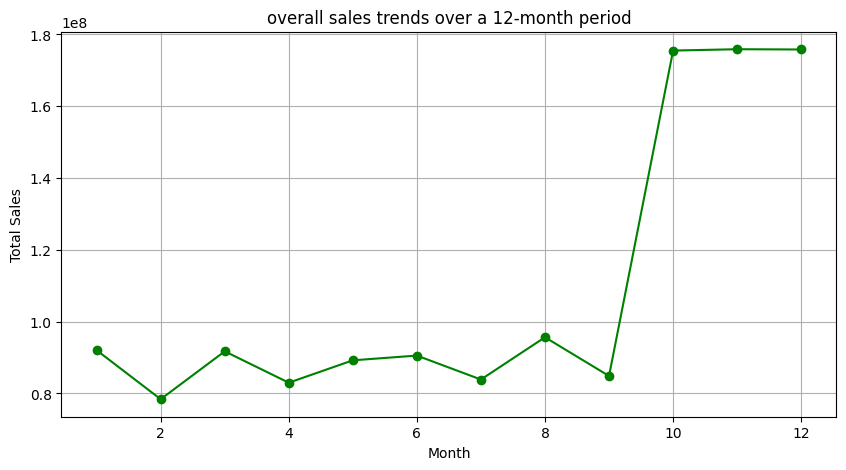

In [46]:
import matplotlib.pyplot as plt

monthly_sales.plot(
    kind='line',
    marker='o',
    figsize=(10,5),
    color='green'
)

plt.title('overall sales trends over a 12-month period')
plt.xlabel('Month')
plt.ylabel('Total Sales')

plt.grid(True)

plt.show()

### Product Category Performance Analysis
> Identifying the best-performing product categories, to perform this analysis, the transactional sales dataset must be combined with the product master dataset using the common `product_id` field.

In [47]:
orders_products = fact_orders.merge(
    dim_products,
    on='product_id',
    how='left'
)

orders_products.head(3)

,order_id,order_date,order_time,customer_id,product_id,store_id,sales_channel,quantity,unit_price,discount_pct,sales_amount,payment_method,product_name,category,sub_category,brand,cost_price,selling_price
0,ORD000001,2025-09-01,16:25:00,CUST02281,PROD0100,STR009,Online,4,35910.88,15,122096.99,Card,Lakme Makeup 100,Beauty,Makeup,Lakme,26163.54,35910.88
1,ORD000002,2025-08-23,11:04:00,CUST01960,PROD0070,STR002,Offline,5,15345.24,0,76726.20,UPI,Decathlon Outdoor 70,Sports,Outdoor,Decathlon,8749.83,15345.24
2,ORD000003,2024-12-01,22:25:00,CUST02026,PROD0248,STR001,Offline,3,6525.56,10,17619.01,Card,Philips Furniture 248,Home & Kitchen,Furniture,Philips,3329.39,6525.56


#### Product Category Revenue Analysis

> The following analysis aggregates total sales revenue by product category using the merged transactional and product datasets.

In [48]:
category_sales = orders_products.groupby(
    'category'
)['sales_amount'].sum().sort_values(ascending=False)

category_sales.apply(lambda x: f"{x:,.2f}")

category
Beauty            330,668,705.19
Fashion           300,797,705.58
Electronics       247,545,026.39
Home & Kitchen    221,342,137.29
Sports            214,650,910.11
electronics         1,476,140.31
Name: sales_amount, dtype: str

#### Category Standardization
> inconsistent categorical values were identified within the `category` column.

For example:
- `Electronics`
- `electronics`

In [49]:
orders_products['category'] = orders_products['category'].str.strip().str.title()

#str.strip removes spaces while str.title makes standardization from electronics to Electronics

In [50]:
# Checking Categories after standardization
orders_products['category'].unique()

<StringArray>
['Beauty', 'Sports', 'Home & Kitchen', 'Electronics', 'Fashion']
Length: 5, dtype: str

#### Product Category Revenue Visualization

> this visualization compare total revenue contribution across different product categories.

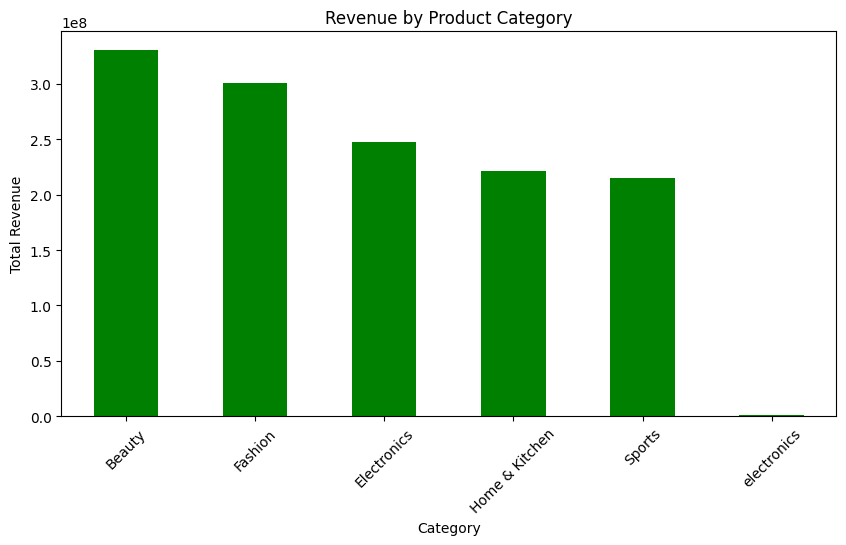

In [51]:
import matplotlib.pyplot as plt

category_sales.plot(
    kind='bar',
    figsize=(10,5),
    color = 'green'
)

plt.title('Revenue by Product Category')
plt.xlabel('Category')
plt.ylabel('Total Revenue')

plt.xticks(rotation=45)

plt.show()

#### Peak Purchasing Hour Analysis
> following step extracts the hourly component from transaction timestamps for time-based sales analysis.

In [52]:
fact_orders['order_hour'] = pd.to_datetime(
    fact_orders['order_time'],
    format='%H:%M:%S'
).dt.hour

fact_orders[['order_time', 'order_hour']].head()

,order_time,order_hour
0,16:25:00,16
1,11:04:00,11
2,22:25:00,22
3,14:48:00,14
4,13:20:00,13


#### Hourly Sales Performance Analysis
> The following analysis aggregates total sales revenue at the hourly level.

In [53]:
hourly_sales = fact_orders.groupby(
    'order_hour'
)['sales_amount'].sum().sort_values(ascending=False)

hourly_sales.apply(lambda x: f"{x:,.2f}")

order_hour
16    91,703,417.30
15    90,898,077.57
22    90,813,820.14
17    90,213,126.84
19    88,947,450.19
9     88,465,574.49
11    88,427,631.82
8     88,282,036.60
20    87,058,280.03
10    86,937,655.49
18    86,165,035.98
13    85,275,031.01
12    85,068,937.46
21    85,054,083.59
14    83,170,466.36
Name: sales_amount, dtype: str

#### Peak Purchasing Hour Visualization
> visualization highlights hourly revenue distribution and peak purchasing behavior patterns.

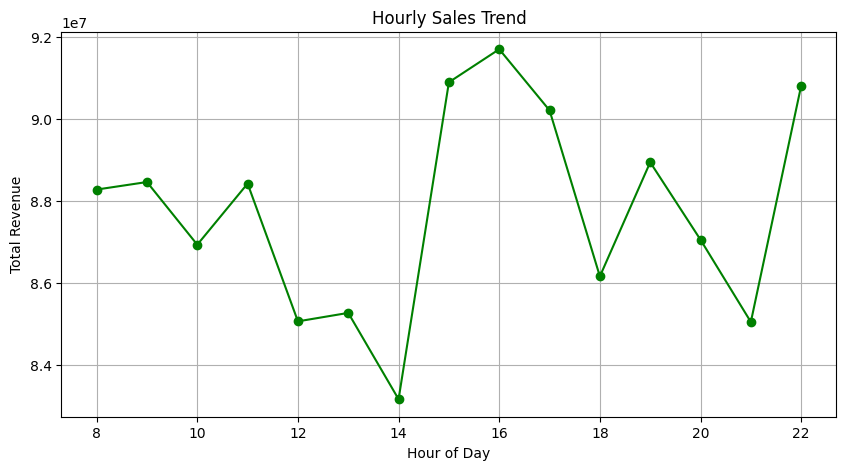

In [54]:
hourly_sales.sort_index().plot(
    kind='line',
    marker='o',
    figsize=(10,5),
    color='green'
)

plt.title('Hourly Sales Trend')
plt.xlabel('Hour of Day')
plt.ylabel('Total Revenue')

plt.grid(True)

plt.show()

### Weekday vs Weekend Sales Analysis
> this will help in comparing weekday and weekend sales performance.

> step extracts the day name from transaction dates to support day-level sales analysis.

In [55]:
fact_orders['day_name'] = fact_orders['order_date'].dt.day_name()

fact_orders[['order_date', 'day_name']].head()

,order_date,day_name
0,2025-09-01,Monday
1,2025-08-23,Saturday
2,2024-12-01,Sunday
3,2025-11-23,Sunday
4,2024-05-18,Saturday


##### Weekday and Weekend Classification
> To compare sales performance across weekdays and weekends, Saturday and Sunday are classified as `Weekend`, while all remaining days are classified as `Weekday`.


In [56]:
fact_orders['week_type'] = fact_orders['day_name'].apply(
    lambda x: 'Weekend' if x in ['Saturday', 'Sunday'] else 'Weekday'
)

fact_orders[['day_name', 'week_type']].head()

,day_name,week_type
0,Monday,Weekday
1,Saturday,Weekend
2,Sunday,Weekend
3,Sunday,Weekend
4,Saturday,Weekend


#### Weekday vs Weekend Revenue Analysis
> This analysis compares total sales revenue generated during weekdays and weekends.


In [57]:
week_sales = fact_orders.groupby(
    'week_type'
)['sales_amount'].sum().sort_values(ascending=False)

week_sales.apply(lambda x: f"{x:,.2f}")

week_type
Weekday    868,375,161.14
Weekend    448,105,463.73
Name: sales_amount, dtype: str

#### Weekday vs Weekend Revenue Visualization
> this visualization is to compare revenue contribution between weekdays and weekends.


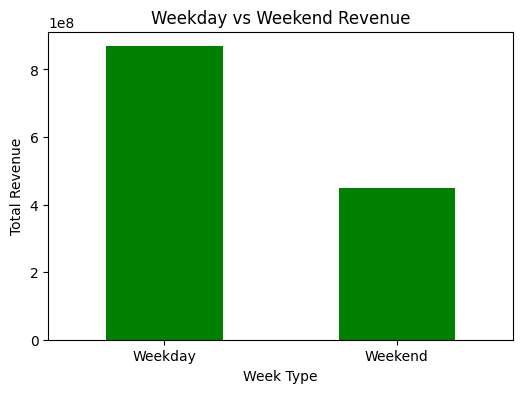

In [58]:
week_sales.plot(
    kind='bar',
    figsize=(6,4),
    color="green"
)

plt.title('Weekday vs Weekend Revenue')
plt.xlabel('Week Type')
plt.ylabel('Total Revenue')

plt.xticks(rotation=0)

plt.show()

#### Fast-Moving Inventory Analysis
> following analysis identifies products with the highest quantity sold across all retail transactions.

In [59]:
fast_moving_products = orders_products.groupby(
    'product_name'
)['quantity'].sum().sort_values(ascending=False)

fast_moving_products.head(10)

product_name
Prestige Furniture 125     344
Nike Footwear 88           343
Decathlon Fitness 142      319
Puma Men Clothing 155      307
Prestige Appliances 111    306
Apple Laptops 219          305
Apple Laptops 135          303
Apple Accessories 4        299
Apple Accessories 87       299
Loreal Skincare 176        299
Name: quantity, dtype: int64

#### Fast-Moving Inventory Visualization
> purpose of this visualization is to identify products with the highest inventory movement across retail operations.

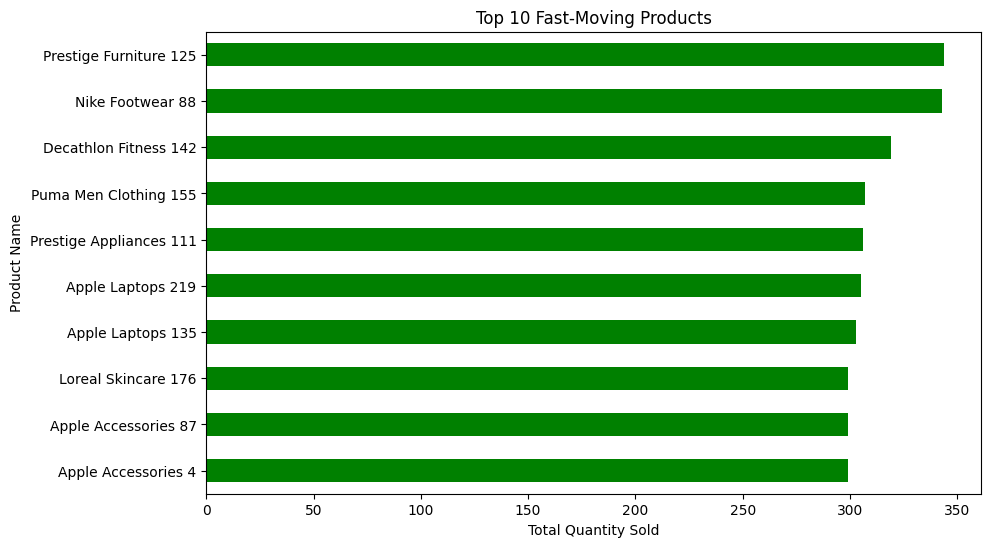

In [60]:
fast_moving_products.head(10).sort_values().plot(
    kind='barh',
    figsize=(10,6),
    color="green"
)

plt.title('Top 10 Fast-Moving Products')
plt.xlabel('Total Quantity Sold')
plt.ylabel('Product Name')

plt.show()

#### Geographic Revenue Analysis
> These steps combines transactional sales data with store location data using the common `store_id` field.

In [61]:
orders_stores = fact_orders.merge(
    dim_stores,
    on='store_id',
    how='left'
)

orders_stores.head()

,order_id,order_date,order_time,customer_id,product_id,store_id,sales_channel,quantity,unit_price,discount_pct,sales_amount,payment_method,order_hour,day_name,week_type,store_name,city,state,region,store_type
0,ORD000001,2025-09-01,16:25:00,CUST02281,PROD0100,STR009,Online,4,35910.88,15,122096.99,Card,16,Monday,Weekday,Pune Retail Hub,Pune,Maharashtra,West,Warehouse
1,ORD000002,2025-08-23,11:04:00,CUST01960,PROD0070,STR002,Offline,5,15345.24,0,76726.20,UPI,11,Saturday,Weekend,Mumbai Retail Hub,Mumbai,Maharashtra,West,Mall
2,ORD000003,2024-12-01,22:25:00,CUST02026,PROD0248,STR001,Offline,3,6525.56,10,17619.01,Card,22,Sunday,Weekend,Delhi Retail Hub,Delhi,Delhi,North,Standalone
3,ORD000004,2025-11-23,14:48:00,CUST00889,PROD0232,STR002,Offline,3,19148.56,5,54573.40,Card,14,Sunday,Weekend,Mumbai Retail Hub,Mumbai,Maharashtra,West,Mall
4,ORD000005,2024-05-18,13:20:00,CUST00589,PROD0055,STR006,Offline,4,30999.85,0,123999.40,UPI,13,Saturday,Weekend,Kolkata Retail Hub,Kolkata,West Bengal,East,Warehouse


##### City-Wise Revenue Analysis
> This analysis aggregates total sales revenue at the city level.

In [62]:
city_revenue = orders_stores.groupby(
    'city'
)['sales_amount'].sum().sort_values(ascending=False)

city_revenue.apply(lambda x: f"{x:,.2f}")

city
Pune          91,877,969.60
Jaipur        90,944,526.17
Indore        90,353,921.66
Kochi         89,227,311.76
Hyderabad     88,754,605.06
Patna         88,393,205.55
Kolkata       88,091,651.05
Bengaluru     87,855,220.40
Chandigarh    87,677,847.44
Noida         87,466,926.86
mumbai        86,489,292.53
Lucknow       86,317,693.17
Delhi         84,856,826.49
Ahmedabad     84,230,912.02
Mumbai        83,942,715.11
Name: sales_amount, dtype: str

##### Geographic Data Standardization
> During city-level revenue analysis, inconsistent city naming formats were identified within the dataset.
 - Mumbai and mumbai were seperate cities

In [63]:
orders_stores['city'] = orders_stores['city'].str.strip().str.title()

##### Verifying

In [64]:
orders_stores['city'].unique()

<StringArray>
[      'Pune',     'Mumbai',      'Delhi',    'Kolkata',  'Hyderabad',
  'Ahmedabad',     'Indore',     'Jaipur',      'Patna',  'Bengaluru',
    'Lucknow',      'Noida',      'Kochi', 'Chandigarh']
Length: 14, dtype: str

##### Standardized City Revenue Analysis
> After standardizing geographic values, city-level revenue analysis was recalculated to ensure accurate regional reporting and KPI generation.

In [65]:
city_revenue = orders_stores.groupby(
    'city'
)['sales_amount'].sum().sort_values(ascending=False)

city_revenue.apply(lambda x: f"{x:,.2f}")

city
Mumbai        170,432,007.64
Pune           91,877,969.60
Jaipur         90,944,526.17
Indore         90,353,921.66
Kochi          89,227,311.76
Hyderabad      88,754,605.06
Patna          88,393,205.55
Kolkata        88,091,651.05
Bengaluru      87,855,220.40
Chandigarh     87,677,847.44
Noida          87,466,926.86
Lucknow        86,317,693.17
Delhi          84,856,826.49
Ahmedabad      84,230,912.02
Name: sales_amount, dtype: str

#### City Revenue Visualization
> The visualization highlights city-wise revenue contribution across retail operations.

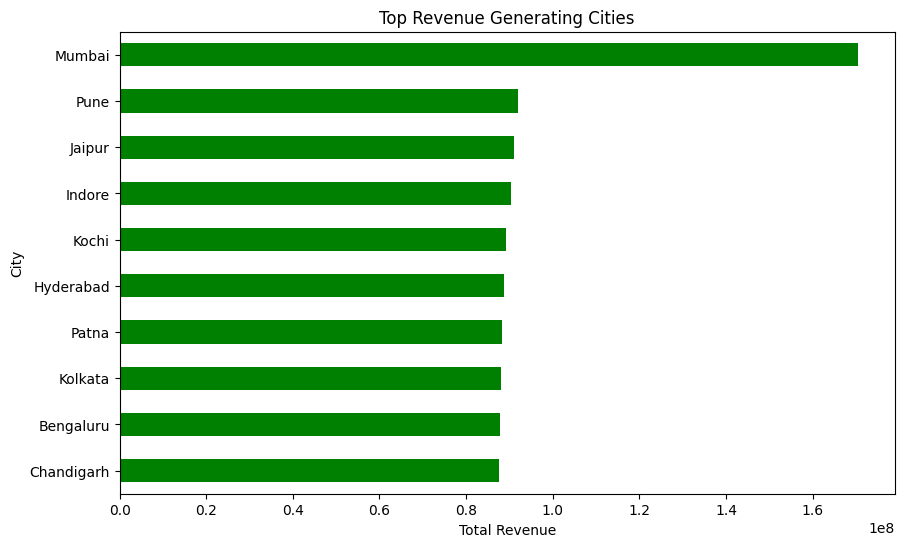

In [66]:
city_revenue.head(10).sort_values().plot(
    kind='barh',
    figsize=(10,6),
    color="green"
)

plt.title('Top Revenue Generating Cities')
plt.xlabel('Total Revenue')
plt.ylabel('City')

plt.show()

#### City-Wise Order Volume Analysis
> This analysis evaluates the number of orders generated across different cities to identify regions with high customer activity.

In [67]:
city_orders = orders_stores.groupby(
    'city'
)['order_id'].count().sort_values(ascending=False)

city_orders

city
Mumbai        2590
Kolkata       1400
Jaipur        1368
Pune          1366
Patna         1357
Bengaluru     1348
Hyderabad     1347
Indore        1336
Chandigarh    1335
Kochi         1331
Noida         1330
Ahmedabad     1303
Delhi         1299
Lucknow       1289
Name: order_id, dtype: int64

#### City-Wise Order Volume Visualization

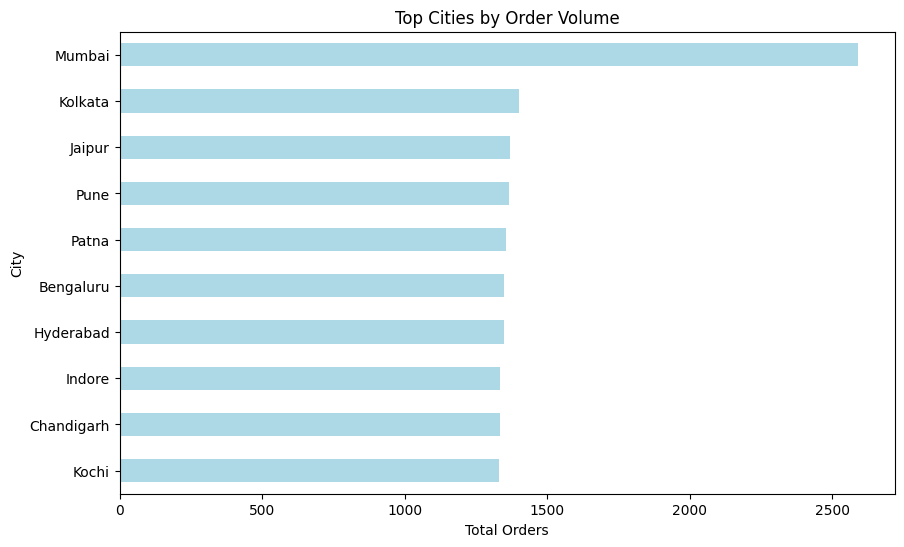

In [68]:
city_orders.head(10).sort_values().plot(
    kind='barh',
    figsize=(10,6),
    color="lightblue"
)

plt.title('Top Cities by Order Volume')
plt.xlabel('Total Orders')
plt.ylabel('City')

plt.show()

#### Dead Stock Analysis Preparation
> combining inventory data with product information to support inventory movement analysis.

In [69]:
inventory_products = fact_inventory.merge(
    dim_products,
    on='product_id',
    how='left'
)

inventory_products.head()

,inventory_id,product_id,store_id,stock_received,stock_sold,current_stock,reorder_level,inventory_date,product_name,category,sub_category,brand,cost_price,selling_price
0,INV00001,PROD0016,STR010,280,4,301,22.0,2024-07-04,Decathlon Fitness 16,Sports,Fitness,Decathlon,7242.63,14677.25
1,INV00002,PROD0090,STR009,59,112,310,52.0,2024-08-11,Reebok Outdoor 90,Sports,Outdoor,Reebok,12577.19,16166.00
2,INV00003,PROD0216,STR003,136,74,326,67.0,2024-09-14,Philips Appliances 216,Home & Kitchen,Appliances,Philips,30946.51,41204.93
3,INV00004,PROD0042,STR003,262,65,231,50.0,2024-10-05,Philips Appliances 42,Home & Kitchen,Appliances,Philips,15008.13,31630.77
4,INV00005,PROD0012,STR012,126,250,6,32.0,2025-04-12,Lakme Skincare 12,Beauty,Skincare,Lakme,7329.63,12573.08


# Geographic Entity Validation & Correction

## Objective
During geographic revenue analysis, an inconsistency was identified between `store_name` and `city` values.

Initially, the issue appeared to be a capitalization inconsistency:
- `Mumbai`
- `mumbai`

However, further business validation revealed that the issue was actually an incorrect city mapping.

Example:
- `store_name = Chennai Retail Hub`
- `city = mumbai`

Since store names across the dataset were aligned with their respective cities, this indicated that:
- `mumbai` was not a formatting issue
- it was an incorrect city entry

To maintain business consistency and accurate geographic KPI reporting, the incorrect city value was corrected using store-level validation.

This validation process is important because incorrect geographic mapping can:
- inflate regional revenue
- distort order volume analysis
- generate misleading dashboard insights

In [70]:
#Validate Store & City Mapping
orders_stores[['store_name', 'city']].drop_duplicates()

,store_name,city
0,Pune Retail Hub,Pune
1,Mumbai Retail Hub,Mumbai
2,Delhi Retail Hub,Delhi
4,Kolkata Retail Hub,Kolkata
5,Hyderabad Retail Hub,Hyderabad
6,Ahmedabad Retail Hub,Ahmedabad
7,Indore Retail Hub,Indore
8,Chennai Retail Hub,Mumbai
9,Jaipur Retail Hub,Jaipur
12,Patna Retail Hub,Patna


In [71]:
#replacing the city name to Chenail where store name is Channai Retail Hub

orders_stores.loc[
    orders_stores['store_name'] == 'Chennai Retail Hub',
    'city'
] = 'Chennai'

In [72]:

# Verifying
orders_stores[['store_name', 'city']].drop_duplicates()

,store_name,city
0,Pune Retail Hub,Pune
1,Mumbai Retail Hub,Mumbai
2,Delhi Retail Hub,Delhi
4,Kolkata Retail Hub,Kolkata
5,Hyderabad Retail Hub,Hyderabad
6,Ahmedabad Retail Hub,Ahmedabad
7,Indore Retail Hub,Indore
8,Chennai Retail Hub,Chennai
9,Jaipur Retail Hub,Jaipur
12,Patna Retail Hub,Patna


## Recalculate Geographic KPIs

#### - Revenue Recalculation

In [73]:

city_revenue = orders_stores.groupby(
    'city'
)['sales_amount'].sum().sort_values(ascending=False)

city_revenue

city
Pune          91877969.60
Jaipur        90944526.17
Indore        90353921.66
Kochi         89227311.76
Hyderabad     88754605.06
Patna         88393205.55
Kolkata       88091651.05
Bengaluru     87855220.40
Chandigarh    87677847.44
Noida         87466926.86
Chennai       86489292.53
Lucknow       86317693.17
Delhi         84856826.49
Ahmedabad     84230912.02
Mumbai        83942715.11
Name: sales_amount, dtype: float64

#### - Order Volume Recalculation

In [74]:
city_orders = orders_stores.groupby(
    'city'
)['order_id'].count().sort_values(ascending=False)

city_orders

city
Kolkata       1400
Jaipur        1368
Pune          1366
Patna         1357
Bengaluru     1348
Hyderabad     1347
Indore        1336
Chandigarh    1335
Kochi         1331
Noida         1330
Chennai       1312
Ahmedabad     1303
Delhi         1299
Lucknow       1289
Mumbai        1278
Name: order_id, dtype: int64

#### - Revenue Recalculation Visualization

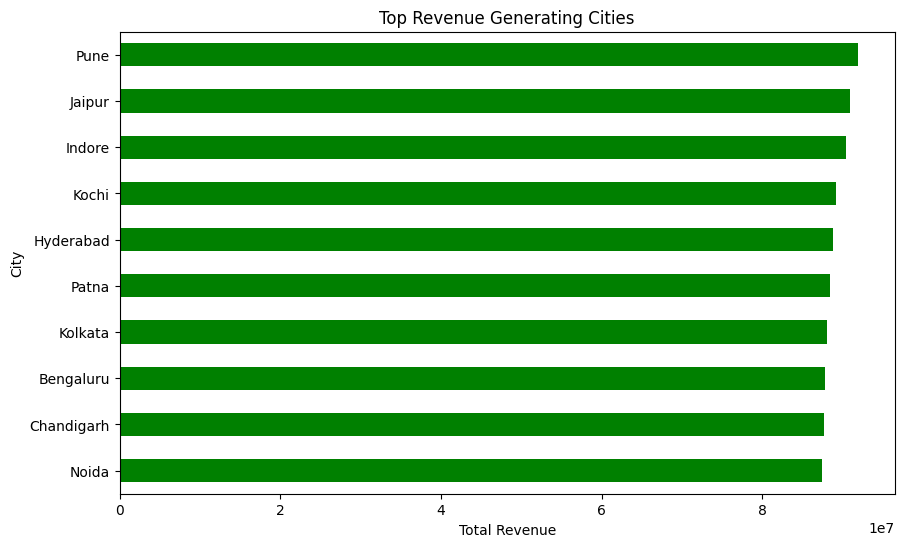

In [75]:
city_revenue.head(10).sort_values().plot(
    kind='barh',
    figsize=(10,6),
    color="green"
)

plt.title('Top Revenue Generating Cities')
plt.xlabel('Total Revenue')
plt.ylabel('City')

plt.show()

#### City-Wise Order Volume Re-calculation Visualization

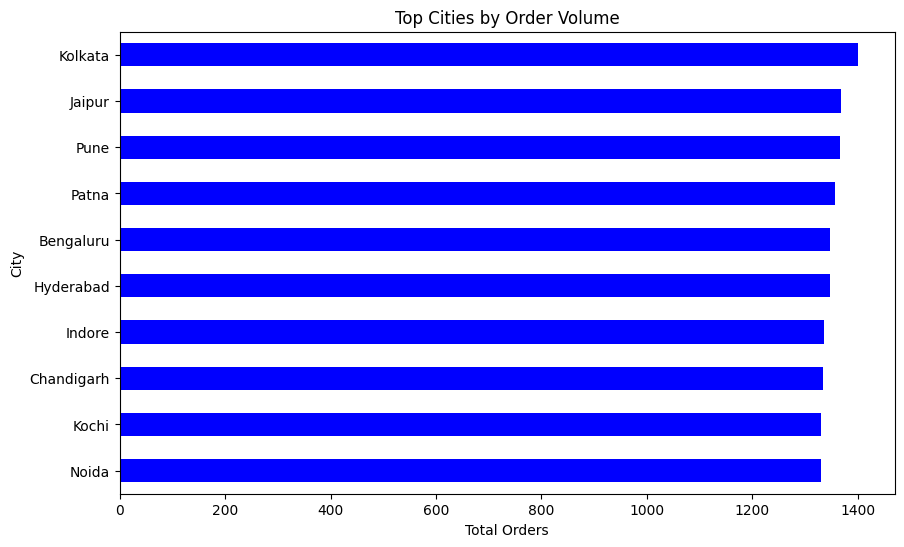

In [76]:
city_orders.head(10).sort_values().plot(
    kind='barh',
    figsize=(10,6),
    color="blue"
)

plt.title('Top Cities by Order Volume')
plt.xlabel('Total Orders')
plt.ylabel('City')

plt.show()

### Dead Stock Candidate Identification
> The following analysis identifies potential dead stock candidates using current inventory levels and stock movement data.

In [77]:
dead_stock_candidates = inventory_products.sort_values(
    by=['current_stock', 'stock_sold'],
    ascending=[False, True]
)

dead_stock_candidates[[
    'product_name',
    'category',
    'current_stock',
    'stock_sold'
]].head(10)

,product_name,category,current_stock,stock_sold
2186,Philips Appliances 223,Home & Kitchen,399,82
1260,Decathlon Fitness 194,Sports,399,85
326,Unknown Product,Beauty,399,107
4794,Samsung Accessories 225,Electronics,399,111
451,Dell Accessories 27,Electronics,399,131
3072,Apple Mobiles 149,Electronics,399,202
573,Samsung Accessories 108,Electronics,399,229
1762,Samsung Accessories 225,Electronics,399,229
2922,Philips Appliances 105,Home & Kitchen,399,236
4792,Decathlon Fitness 66,Sports,399,239


### Inventory Movement Ratio Analysis

#### Objective
To improve dead stock identification accuracy, inventory movement efficiency was measured using a stock movement ratio.

The ratio compares:
- stock sold
with
- current stock available

Lower ratios may indicate:
- weak product movement
- overstock conditions
- inefficient inventory allocation

This analysis helps identify products requiring further inventory review.

In [78]:
inventory_products['movement_ratio'] = (
    inventory_products['stock_sold'] /
    inventory_products['current_stock']
)

##### Identify Low Movement Products

In [79]:
low_movement_products = inventory_products.sort_values(
    by='movement_ratio'
)

low_movement_products[[
    'product_id',
    'product_name',
    'category',
    'current_stock',
    'stock_sold',
    'movement_ratio'
]].head(10)

,product_id,product_name,category,current_stock,stock_sold,movement_ratio
15,PROD0102,Lakme Skincare 102,Beauty,-10,248,-24.8
6,PROD0243,Philips Appliances 243,Home & Kitchen,87,0,0.0
2257,PROD0179,Decathlon Fitness 179,Sports,196,0,0.0
2374,PROD0023,Lakme Makeup 23,Beauty,254,0,0.0
4548,PROD0232,Decathlon Outdoor 232,Sports,190,0,0.0
2066,PROD0088,Nike Footwear 88,Fashion,391,0,0.0
3781,PROD0241,Loreal Makeup 241,Beauty,219,0,0.0
4101,PROD0184,Puma Men Clothing 184,Fashion,280,0,0.0
1774,PROD0085,Lakme Makeup 85,Beauty,339,0,0.0
702,PROD0120,Nike Men Clothing 120,Fashion,170,0,0.0


In [80]:
low_movement_products.head(10)

,inventory_id,product_id,store_id,stock_received,stock_sold,current_stock,reorder_level,inventory_date,product_name,category,sub_category,brand,cost_price,selling_price,movement_ratio
15,INV00016,PROD0102,STR002,43,248,-10,50.0,2024-03-12,Lakme Skincare 102,Beauty,Skincare,Lakme,24996.83,44309.49,-24.8
6,INV00007,PROD0243,STR008,288,0,87,26.0,2024-08-09,Philips Appliances 243,Home & Kitchen,Appliances,Philips,1290.17,1959.27,0.0
2257,INV02258,PROD0179,STR006,495,0,196,54.0,2025-02-07,Decathlon Fitness 179,Sports,Fitness,Decathlon,25955.86,46203.24,0.0
2374,INV02375,PROD0023,STR010,377,0,254,23.0,2024-05-01,Lakme Makeup 23,Beauty,Makeup,Lakme,15190.51,22778.66,0.0
4548,INV04549,PROD0232,STR008,91,0,190,16.0,2025-02-14,Decathlon Outdoor 232,Sports,Outdoor,Decathlon,14101.07,19148.56,0.0
2066,INV02067,PROD0088,STR005,228,0,391,44.0,2025-02-24,Nike Footwear 88,Fashion,Footwear,Nike,14905.67,26855.84,0.0
3781,INV03782,PROD0241,STR004,374,0,219,12.0,2025-11-29,Loreal Makeup 241,Beauty,Makeup,Loreal,20186.31,25795.93,0.0
4101,INV04102,PROD0184,STR010,45,0,280,66.0,2025-05-08,Puma Men Clothing 184,Fashion,Men Clothing,Puma,26400.77,41156.24,0.0
1774,INV01775,PROD0085,STR004,313,0,339,51.0,2025-09-11,Lakme Makeup 85,Beauty,Makeup,Lakme,8970.24,19215.74,0.0
702,INV00703,PROD0120,STR003,26,0,170,33.0,2024-04-05,Nike Men Clothing 120,Fashion,Men Clothing,Nike,6334.68,9483.43,0.0


### Inventory Validation Check

#### Objective
During inventory movement analysis, invalid inventory values were identified within the dataset.

Example:
- negative current stock values

Since inventory stock cannot logically be negative in normal retail operations, these records were treated as invalid inventory entries.

To maintain analytical accuracy:
- rows with negative inventory values were removed before continuing dead stock analysis.

This validation step helps ensure:
- reliable inventory KPIs
- accurate stock movement analysis
- meaningful dead stock identification

In [81]:
# removing values lower than 0 in current stock
inventory_products = inventory_products[
    inventory_products['current_stock'] >= 0
]

In [82]:
# Verifying
(inventory_products['current_stock'] < 0).sum()

np.int64(0)

### Recalculation of Inventory Movement Ratio

In [83]:
inventory_products['movement_ratio'] = (
    inventory_products['stock_sold'] /
    inventory_products['current_stock']
)

In [84]:
low_movement_products = inventory_products.sort_values(
    by='movement_ratio'
)

low_movement_products[[
    'product_name',
    'category',
    'current_stock',
    'stock_sold',
    'movement_ratio'
]].head(10)

,product_name,category,current_stock,stock_sold,movement_ratio
6,Philips Appliances 243,Home & Kitchen,87,0,0.0
1774,Lakme Makeup 85,Beauty,339,0,0.0
4608,Philips Furniture 188,Home & Kitchen,75,0,0.0
2066,Nike Footwear 88,Fashion,391,0,0.0
648,Nike Men Clothing 166,Fashion,358,0,0.0
4548,Decathlon Outdoor 232,Sports,190,0,0.0
384,Prestige Appliances 229,Home & Kitchen,296,0,0.0
3603,Lakme Makeup 34,Beauty,70,0,0.0
3069,Puma Footwear 165,Fashion,24,0,0.0
2374,Lakme Makeup 23,Beauty,254,0,0.0


### Low-Movement Inventory Visualization

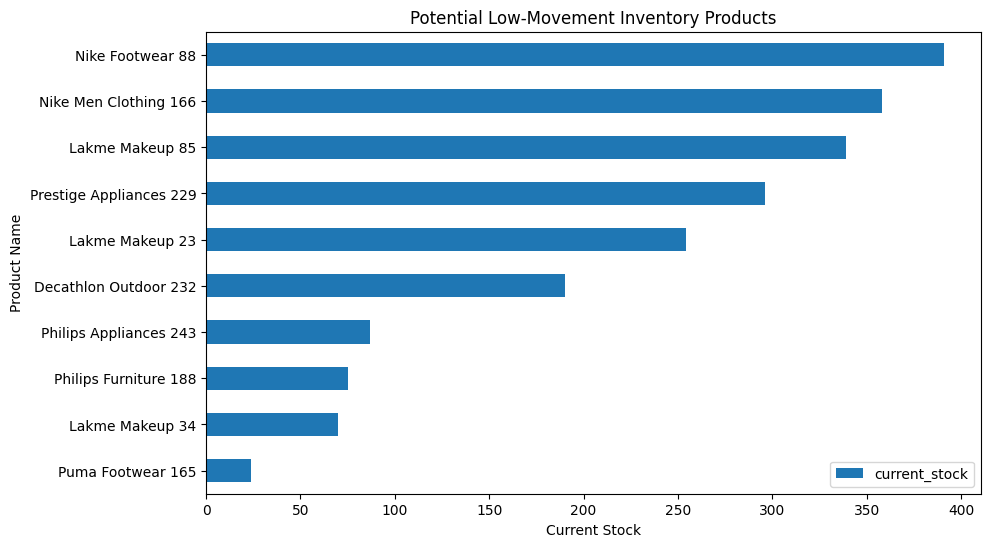

In [85]:
low_movement_products.head(10).sort_values(
    by='current_stock'
).plot(
    x='product_name',
    y='current_stock',
    kind='barh',
    figsize=(10,6)
)

plt.title('Potential Low-Movement Inventory Products')
plt.xlabel('Current Stock')
plt.ylabel('Product Name')

plt.show()

#### Reorder Level Analysis
> This analysis identifies products approaching or falling below their reorder threshold levels, products with inventory levels close to or below reorder thresholds may require procurement attention.

In [98]:
reorder_products = inventory_products[
    inventory_products['current_stock'] <=
    inventory_products['reorder_level']
]

In [99]:
reorder_category = reorder_products.groupby(
    'category'
)['product_id'].count().sort_values(
    ascending=False
)

reorder_category

category
Beauty            147
Electronics       125
Home & Kitchen    115
Fashion           109
Sports             95
Name: product_id, dtype: int64

#### Reorder Risk KPI
> This KPI measures the number of products currently operating below their reorder threshold levels.


In [100]:
reorder_risk_count = reorder_products.shape[0]

print(
    "Total Products Below Reorder Level:",
    reorder_risk_count
)

Total Products Below Reorder Level: 591


##### Operational Insight

- A large number of products may require procurement attention soon.

### Category-Level Reorder Risk Analysis
> This analysis evaluates reorder risk across different product categories.

In [101]:
reorder_category = reorder_products.groupby(
    'category'
)['product_id'].count().sort_values(
    ascending=False
)

reorder_category

category
Beauty            147
Electronics       125
Home & Kitchen    115
Fashion           109
Sports             95
Name: product_id, dtype: int64